In [14]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 





In [15]:
df_best=pd.read_csv('tables/best_ms_method_per_model.csv')
df_best_min_max=pd.read_csv('tables/ms_best_min_max.csv')

### Group by AIS -, regions-mean (amundesen,FRIS,ROSS) and EAST,WEST ) module score


In [16]:
regions = ['AIS',
 'Amundsen',
 'Ross',
 'FilchnerRonne',
           'Aurora',
           'Wilkes'
    ]
index =np.argsort(df_best['melt_sensetivity_AIS'].values)
index = index[::-1]

## Main Figure

In [17]:
colors = ['black','#882255', '#44AA99', '#117733', '#332288', '#DDCC77']


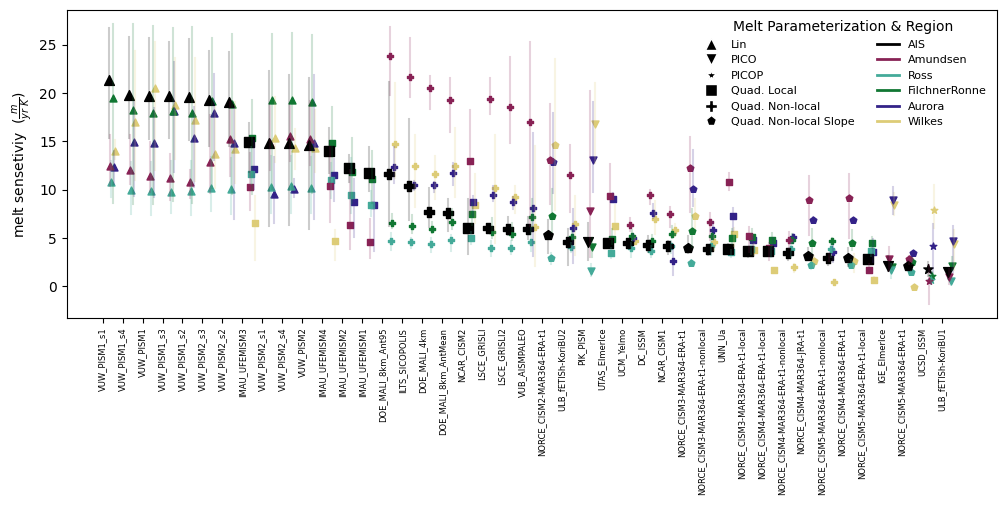

In [18]:
to_m_k_a = 10**3/917 #t into kg into m3
param_u =np.unique(df_best['parameterization'])
marker_u = ['^','v','*','s','P','p']
dic_marker = {}
for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_best['parameterization'][index]:
    markers.append(dic_marker[key])

for key in df_best['parameterization'][msk]:
    marker_nomodel.append(dic_marker[key])

f,ax = plt.subplots(1,1,figsize =(12,4))
# colors = ['black', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i,region in enumerate(regions[::-1]):
    y = df_best_min_max[f'melt_sensetivity_{region}'].values[index]
    y_err_lower = df_best_min_max[f'min_melt_sensetivity_{region}'].values[index]
    y_err_upper =df_best_min_max[f'max_melt_sensetivity_{region}'].values[index] 
    xall = np.arange(len(index))*8+5 -0.5 *i
    
    for j, yl in enumerate(y_err_lower):
        yu = y_err_upper[j]
        ym = y[j]
        x=xall[j]
        if i == 5:
            plt.scatter(x,ym*to_m_k_a ,marker=markers[j],  color=colors[::-1][i],s = 50)
        else:
            plt.scatter(x,ym*to_m_k_a,marker=markers[j],  color=colors[::-1][i],s=25)
        
        plt.plot([x,x],[yl*to_m_k_a,yu*to_m_k_a] ,  color=colors[::-1][i],alpha =0.2)
        
#     break

ax.set_xticks(np.arange(len(index))*8)
ax.set_xticklabels(df_best['Model'].values[index], rotation = 90,fontsize =6)
ax.set_ylabel('melt sensetiviy  ($\\frac{m}{yr~ K}$)')
# 


# Legend for markers
marker_handles = [plt.Line2D([0], [0], marker=marker_u[i], color='w', 
                             markerfacecolor='k', markersize=8, 
                             label=param_u[i]) 
                  for i in range(len(param_u))]

# Legend for colors
color_handles = [plt.Line2D([0], [0], color=colors[i], lw=2, 
                            label=region) 
                 for i, region in enumerate(regions)]
# Combine marker and color legends into one
combined_handles = marker_handles + color_handles
combined_labels = param_u.tolist() + regions

# Add the combined legend
ax.legend(handles=combined_handles, labels=combined_labels, title="Melt Parameterization & Region", 
          loc='upper right', bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize = 8)
# Your existing code here...

# Save the figure with tight bounding box
f.savefig('figs/paper/melt_sensetivity_region_m_K_a.pdf', bbox_inches='tight')
f.savefig('figs/paper/melt_sensetivity_region_m_K_a.jpeg', bbox_inches='tight')
f.savefig('figs/paper/Fig3.pdf', bbox_inches='tight')
f.savefig('figs/paper/Fig3.jpeg', bbox_inches='tight')


In [20]:
df_best_min_max_alpha = df_best_min_max.sort_values(by='Model', ascending=True)

In [23]:
from docx import Document


# Example DataFrame
data = {
    'MS AIS': np.round(df_best_min_max_alpha['melt_sensetivity_AIS'].values*to_m_k_a,1),
    'MS MIN': np.round(df_best_min_max_alpha['min_melt_sensetivity_AIS'].values*to_m_k_a),
    'MS MAX': np.round(df_best_min_max_alpha['max_melt_sensetivity_AIS'].values*to_m_k_a)
}
df = pd.DataFrame(data)

# Create a Word document
doc = Document()

# Add a table
table = doc.add_table(rows=1, cols=len(df.columns))

# Add header row
hdr_cells = table.rows[0].cells
for i, col_name in enumerate(df.columns):
    hdr_cells[i].text = col_name

# Add the DataFrame rows to the table
for _, row in df.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# Save the Word document
doc.save('tables/mss_table.docx')


In [10]:
df_best_min_max_alpha['melt_sensetivity_AIS'].values.to_m_k_a

array([ 4.29743285,  7.73313613, 11.59869287,  7.53101805,  2.0579909 ,
       10.39230794, 11.66600928, 12.27574305, 14.92229804, 13.98540953,
        6.00605348,  5.93514183,  4.13560207,  6.00853102,  5.31155102,
        3.98409591,  3.65216514,  3.88471146,  2.93961047,  3.61736529,
        3.44085972,  3.14674987,  2.04264589,  2.81109635,  2.94237693,
        4.53571032,  4.43796988,  1.81899681,  1.4652857 ,  4.53997617,
        3.85938045,  4.47947815,  5.9220353 , 19.68471432, 21.28958362,
       19.62737658, 19.64205454, 19.7509699 , 14.57983002, 14.823373  ,
       19.08466922, 19.25600514, 14.7899301 ])